# Assignment 3: Image Classification using CNN on CIFAR-10 Dataset

In [2]:
# Phase 1: Import Required Libraries

# PyTorch Core Library
import torch
# Neural Network Modules
import torch.nn as nn

# Optimization Algorithms
import torch.optim as optim

# Computer Vision Utilities
import torchvision
import torchvision.transforms as transforms

# Data Loading Utilities
from torch.utils.data import DataLoader

# Data Visualization
import matplotlib.pyplot as plt

# Numerical Operations
import numpy as np

In [3]:
# Phase 2: Load and Preprocess the CIFAR-10 Dataset

# Define image transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

# Load the training dataset
train_dataset = torchvision.datasets.CIFAR10(
    root="../datasets/cifar10",
    train=True,
    download=True,
    transform=transform
)

# Load the testing dataset
test_dataset = torchvision.datasets.CIFAR10(
    root="../datasets/cifar10",
    train=False,
    download=True,
    transform=transform
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

Training Images : 50000
Testing Images  : 10000
CIFAR-10 Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image Batch Shape : torch.Size([64, 3, 32, 32])
Label Batch Shape : torch.Size([64])


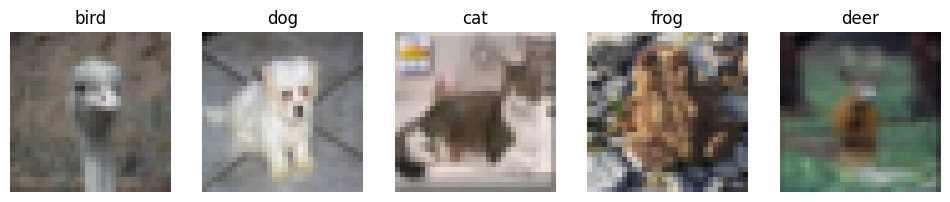

In [4]:
# Phase 3: Dataset Exploration

# Display the number of images in the training and testing datasets
print("Training Images :", len(train_dataset))
print("Testing Images  :", len(test_dataset))

# Display the class names in the CIFAR-10 dataset
print("CIFAR-10 Classes:")
print(train_dataset.classes)

# Load one batch of training data
images, labels = next(iter(train_loader))
print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

# Display a few sample images from the training dataset
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image = images[i] / 2 + 0.5          # Reverse normalization
    image = image.numpy().transpose((1, 2, 0))

    axes[i].imshow(image)
    axes[i].set_title(train_dataset.classes[labels[i]])
    axes[i].axis("off")

plt.show()

In [5]:
# Phase 4: Design the CNN Architecture

class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        # First Convolutional Block
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu1 = nn.ReLU()

        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Second Convolutional Block
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.relu2 = nn.ReLU()

        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Fully Connected Layers
        self.fc1 = nn.Linear(
            64 * 8 * 8,
            512
        )

        self.relu3 = nn.ReLU()

        self.fc2 = nn.Linear(
            512,
            10
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu3(x)

        x = self.fc2(x)

        return x

In [7]:
# Phase 5: Configure the Model

# Select the device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# Create the CNN model
model = CNN().to(device)
# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Display the model architecture

print(model)

Using Device: cpu
CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


In [8]:
# Phase 6: Train the CNN Model

# Number of training epochs
num_epochs = 10
# Store training loss for each epoch
train_losses = []

# Train the CNN model
for epoch in range(num_epochs):
    # Set the model to training mode
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        # Move data to the selected device
        images = images.to(device)
        labels = labels.to(device)
        # Clear previous gradients
        optimizer.zero_grad()
        # Forward pass
        outputs = model(images)
        # Calculate loss
        loss = criterion(outputs, labels)
        # Backpropagation
        loss.backward()
        # Update model parameters
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}")

Epoch [1/10] - Loss: 1.2737
Epoch [2/10] - Loss: 0.8896
Epoch [3/10] - Loss: 0.6953
Epoch [4/10] - Loss: 0.5273
Epoch [5/10] - Loss: 0.3684
Epoch [6/10] - Loss: 0.2341
Epoch [7/10] - Loss: 0.1423
Epoch [8/10] - Loss: 0.0938
Epoch [9/10] - Loss: 0.0796
Epoch [10/10] - Loss: 0.0645


In [9]:
# Phase 7: Evaluate the Model

# Evaluate the trained model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

In [10]:
# Phase 8: Model Performance Evaluation

# Calculate test accuracy
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 72.55%


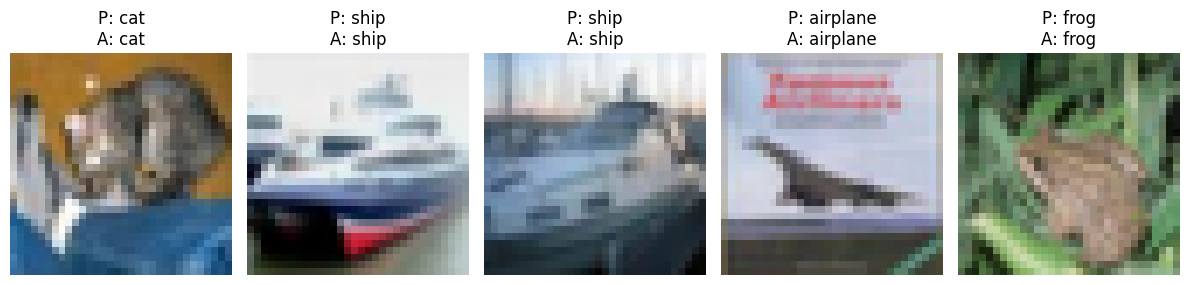

In [11]:
# Phase 9: Visualize Model Predictions

# Display sample predictions
classes = train_dataset.classes
images, labels = next(iter(test_loader))
images = images.to(device)
outputs = model(images)
_, predicted = torch.max(outputs, 1)
images = images.cpu()
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    image = images[i] / 2 + 0.5
    image = image.numpy().transpose((1, 2, 0))
    axes[i].imshow(image)
    axes[i].set_title(f"P: {classes[predicted[i]]}\nA: {classes[labels[i]]}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## Conclusion

In this assignment, a Convolutional Neural Network (CNN) was implemented using PyTorch for image classification on the CIFAR-10 dataset.

The project included:
- Loading and preprocessing the CIFAR-10 dataset.
- Designing a CNN architecture with convolutional, pooling, and fully connected layers.
- Training the model using backpropagation and the Adam optimizer.
- Evaluating the model using classification accuracy.
- Visualizing sample predictions on test images.

The trained CNN successfully learned image features and achieved competitive performance on the CIFAR-10 dataset, demonstrating the effectiveness of deep learning for image classification tasks.